### **PART 1: LOAD & PREPARE DATA**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dimensi0n/afhq-512")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'afhq-512' dataset.
Path to dataset files: /kaggle/input/afhq-512


In [ ]:
import os
print(sorted(os.listdir(path)))

['cat', 'dog', 'wild']


In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

random_seed = 42

import torch

torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)

cat_path = os.path.join(path, 'cat')
dog_path = os.path.join(path, 'dog')
wild_path = os.path.join(path, 'wild')

cat_files = [os.path.join(cat_path, f) for f in sorted(os.listdir(cat_path))]
dog_files = [os.path.join(dog_path, f) for f in sorted(os.listdir(dog_path))]
wild_files = [os.path.join(wild_path, f) for f in sorted(os.listdir(wild_path))]

print(f"Cat: {len(cat_files)} | Dog: {len(dog_files)} | Wild: {len(wild_files)}")

# Label: 0 = cat, 1 = dog, 2 = wild (non-target)
all_files = cat_files + dog_files + wild_files
all_labels = [0]*len(cat_files) + [1]*len(dog_files) + [2]*len(wild_files)

train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=random_seed
)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=random_seed
)

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Cat: 5558 | Dog: 5169 | Wild: 5076
Train: 11062 | Val: 2370 | Test: 2371


### **PART 2: CUSTOM DATASETS CLASS & PRE-PROCESSING**

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

def filter_valid(files, labels):
    ok_f, ok_l = [], []
    for f, l in zip(files, labels):
        try:
            with Image.open(f) as im: im.verify()
            ok_f.append(f); ok_l.append(l)
        except Exception:
            print("Skipping:", f)
    return ok_f, ok_l

train_files, train_labels = filter_valid(train_files, train_labels)
val_files,   val_labels   = filter_valid(val_files,   val_labels)
test_files,  test_labels  = filter_valid(test_files,  test_labels)

class AnimalDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = AnimalDataset(train_files, train_labels, transform=transform)
val_dataset = AnimalDataset(val_files, val_labels, transform=transform)
test_dataset = AnimalDataset(test_files, test_labels, transform=transform)

### **PART 3: FEATURE EXTRACTION (FROZEN BACKBONES)**

In [ ]:
import time, copy, json, random
import numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

R = {}  # collects every result, printed as JSON at the end
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)  # should print cuda
class_names = ['Cat', 'Dog', 'Wild']
WILD = 2
R['split_sizes'] = dict(train=len(train_files), val=len(val_files), test=len(test_files))

# Backbones are ALWAYS kept in eval() mode so BatchNorm uses its pretrained running
# statistics -> the backbone is truly frozen (requires_grad=False alone does not do this).
mnet = models.mobilenet_v2(weights='IMAGENET1K_V1').to(device).eval()
rnet = models.resnet18(weights='IMAGENET1K_V1').to(device).eval()
rnet.fc = nn.Identity()  # ResNet18 -> 512-d feature vector

@torch.no_grad()
def extract(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
    Fm, Fr, Y = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        f = nn.functional.adaptive_avg_pool2d(mnet.features(x), 1).flatten(1)  # (B, 1280)
        Fm.append(f.cpu()); Fr.append(rnet(x).cpu()); Y.append(y)
    return torch.cat(Fm), torch.cat(Fr), torch.cat(Y)

t0 = time.time()
tr_m, tr_r, tr_y = extract(train_dataset)
va_m, va_r, va_y = extract(val_dataset)
te_m, te_r, te_y = extract(test_dataset)
print(f"Feature extraction: {time.time()-t0:.0f}s", tr_m.shape, tr_r.shape)

# Backbone size / CPU latency comparison (justifies MobileNetV2 for an embedded feeder)
mc, rc = copy.deepcopy(mnet).cpu().eval(), copy.deepcopy(rnet).cpu().eval()
x1 = torch.randn(1, 3, 224, 224)
def ms_per_img(f, n=30):
    with torch.no_grad():
        for _ in range(5): f(x1)
        t = time.time()
        for _ in range(n): f(x1)
    return (time.time() - t) / n * 1000
R['backbone_compare'] = dict(
    mobilenetv2_backbone_params_M=sum(p.numel() for p in mnet.features.parameters()) / 1e6,
    resnet18_backbone_params_M=sum(p.numel() for p in rnet.parameters()) / 1e6,
    mobilenetv2_cpu_ms_per_img=ms_per_img(lambda x: mc.features(x)),
    resnet18_cpu_ms_per_img=ms_per_img(rc))
print(R['backbone_compare'])
del mc, rc

device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 115MB/s] 


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


Feature extraction: 197s torch.Size([11062, 1280]) torch.Size([11062, 512])
{'mobilenetv2_backbone_params_M': 2.223872, 'resnet18_backbone_params_M': 11.176512, 'mobilenetv2_cpu_ms_per_img': 23.650415738423668, 'resnet18_cpu_ms_per_img': 55.596963564554855}


### **PART 4: TRAINING LOOP AND METRICS**

In [ ]:
from sklearn.metrics import fbeta_score, classification_report, confusion_matrix
from scipy.stats import beta as beta_dist

def set_seed(s):
    torch.manual_seed(s); torch.cuda.manual_seed_all(s); np.random.seed(s); random.seed(s)

def make_head(d):  # same structure as MobileNetV2's classifier, with 3 outputs
    return nn.Sequential(nn.Dropout(0.2), nn.Linear(d, 3))

eval_crit = nn.CrossEntropyLoss()

def train_head(Ftr, Ytr, Fva, Yva, seed=42, class_weights=None, epochs=10, lr=1e-4, bs=32, verbose=False):
    set_seed(seed)
    head = make_head(Ftr.shape[1]).to(device)
    w = None if class_weights is None else torch.tensor(class_weights, dtype=torch.float32, device=device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = optim.Adam(head.parameters(), lr=lr)
    Ftr, Ytr, Fva, Yva = Ftr.to(device), Ytr.to(device), Fva.to(device), Yva.to(device)
    n = len(Ftr)
    hist = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']}
    for ep in range(epochs):
        head.train()
        perm = torch.randperm(n, device=device)
        tot_loss = tot_corr = 0.0
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            out = head(Ftr[idx])
            loss = crit(out, Ytr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
            tot_loss += loss.item() * len(idx)
            tot_corr += (out.argmax(1) == Ytr[idx]).sum().item()
        head.eval()
        with torch.no_grad():
            vo = head(Fva)
            hist['val_loss'].append(eval_crit(vo, Yva).item())
            hist['val_acc'].append((vo.argmax(1) == Yva).float().mean().item())
        hist['train_loss'].append(tot_loss / n); hist['train_acc'].append(tot_corr / n)
        if verbose:
            print(f"Epoch {ep+1}/{epochs} | Train Loss {hist['train_loss'][-1]:.4f} | "
                  f"Val Loss {hist['val_loss'][-1]:.4f} | Val Acc {hist['val_acc'][-1]:.4f}")
    return head, hist

@torch.no_grad()
def probs_of(head, F):
    head.eval()
    return torch.softmax(head(F.to(device)), 1).cpu().numpy()

def summarize(P, Y, tau=None, c_fn=5, c_fp=1):
    """Binary view: pet (cat/dog) = positive class. FN = pet predicted as wild (the costly error).
    tau=None -> argmax rule; otherwise open the tray if P(wild) < tau."""
    pred = P.argmax(1)
    is_pet = Y != WILD
    pred_pet = (pred != WILD) if tau is None else (P[:, WILD] < tau)
    tp = int((pred_pet & is_pet).sum()); fn = int((~pred_pet & is_pet).sum()); fp = int((pred_pet & ~is_pet).sum())
    rec = tp / max(tp + fn, 1); prec = tp / max(tp + fp, 1)
    f2 = 5 * prec * rec / max(4 * prec + rec, 1e-9)
    return dict(acc=float((pred == Y).mean()), pet_recall=rec, pet_prec=prec, pet_F2=f2,
                FN=fn, FP=fp, cost=c_fn * fn + c_fp * fp, tp=tp, n_pet=int(is_pet.sum()))

def cp_ci(k, n, a=0.05):  # Clopper-Pearson 95% confidence interval
    lo = 0.0 if k == 0 else beta_dist.ppf(a / 2, k, n - k + 1)
    hi = 1.0 if k == n else beta_dist.ppf(1 - a / 2, k + 1, n - k)
    return round(float(lo), 4), round(float(hi), 4)

Epoch 1/10 | Train Loss 0.3195 | Val Loss 0.1009 | Val Acc 0.9890
Epoch 2/10 | Train Loss 0.0744 | Val Loss 0.0523 | Val Acc 0.9924
Epoch 3/10 | Train Loss 0.0451 | Val Loss 0.0364 | Val Acc 0.9941
Epoch 4/10 | Train Loss 0.0332 | Val Loss 0.0296 | Val Acc 0.9937
Epoch 5/10 | Train Loss 0.0266 | Val Loss 0.0261 | Val Acc 0.9932
Epoch 6/10 | Train Loss 0.0224 | Val Loss 0.0208 | Val Acc 0.9954
Epoch 7/10 | Train Loss 0.0191 | Val Loss 0.0188 | Val Acc 0.9954
Epoch 8/10 | Train Loss 0.0182 | Val Loss 0.0171 | Val Acc 0.9954
Epoch 9/10 | Train Loss 0.0166 | Val Loss 0.0162 | Val Acc 0.9958
Epoch 10/10 | Train Loss 0.0146 | Val Loss 0.0157 | Val Acc 0.9958
              precision    recall  f1-score   support

         Cat     1.0000    0.9964    0.9982       834
         Dog     0.9898    0.9974    0.9936       776
        Wild     0.9947    0.9908    0.9928       761

    accuracy                         0.9949      2371
   macro avg     0.9948    0.9949    0.9948      2371
weighted avg 

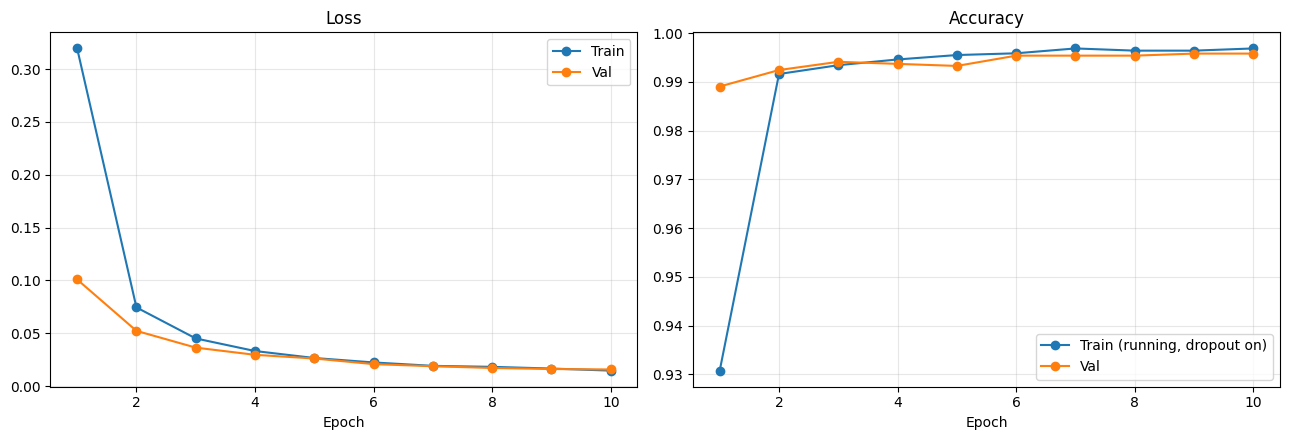

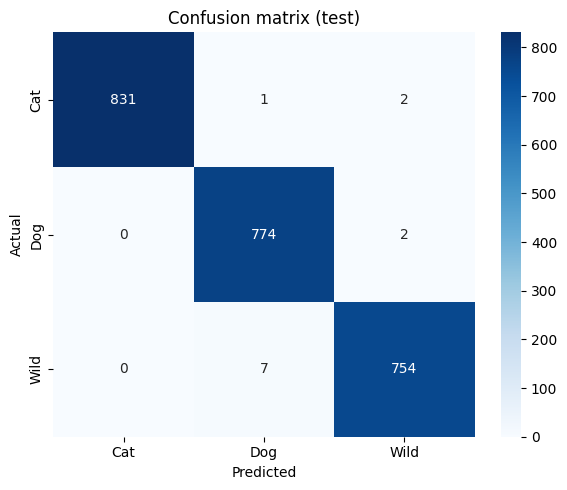

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns

Y_va, Y_te = va_y.numpy(), te_y.numpy()
head_main, hist = train_head(tr_m, tr_y, va_m, va_y, seed=42, verbose=True)
P_va, P_te = probs_of(head_main, va_m), probs_of(head_main, te_m)
pred_te = P_te.argmax(1)

print(classification_report(Y_te, pred_te, target_names=class_names, digits=4))
cm = confusion_matrix(Y_te, pred_te); print(cm)
s = summarize(P_te, Y_te); ci = cp_ci(s['tp'], s['n_pet'])
train_acc_eval = float((probs_of(head_main, tr_m).argmax(1) == tr_y.numpy()).mean())
print("Test (binary pet-vs-wild view):", s, "| pet-recall 95% CI:", ci)
print("Original macro-F2:", fbeta_score(Y_te, pred_te, beta=2, average='macro'),
      "| train accuracy (eval mode):", train_acc_eval)
R['main'] = dict(test=s, pet_recall_CI=ci,
                 macro_F2=float(fbeta_score(Y_te, pred_te, beta=2, average='macro')),
                 cm=cm.tolist(), train_acc_eval=train_acc_eval,
                 last_epoch={k: v[-1] for k, v in hist.items()})

# Trivial baselines
rng = np.random.default_rng(0); n = len(Y_te)
maj = int(np.bincount(tr_y.numpy()).argmax())
base = {'majority class': np.eye(3)[np.full(n, maj)],
        'uniform random': rng.random((n, 3)),
        'always Wild': np.eye(3)[np.full(n, 2)]}
R['baselines'] = {k: summarize(v, Y_te) for k, v in base.items()}
for k, v in R['baselines'].items(): print(k, v)

# Figures
ep = range(1, 11)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, hist['train_loss'], 'o-', label='Train'); ax[0].plot(ep, hist['val_loss'], 'o-', label='Val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep, hist['train_acc'], 'o-', label='Train (running, dropout on)'); ax[1].plot(ep, hist['val_acc'], 'o-', label='Val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig('loss_curve.png', dpi=150); plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion matrix (test)')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()

In [ ]:
configs = {
    'MobileNetV2 CE':            (tr_m, va_m, te_m, None),
    'MobileNetV2 w=[1.5,1.5,1]': (tr_m, va_m, te_m, [1.5, 1.5, 1.0]),
    'MobileNetV2 w=[5,5,1]':     (tr_m, va_m, te_m, [5.0, 5.0, 1.0]),
    'ResNet18 CE':               (tr_r, va_r, te_r, None),
}
R['multi_seed'] = {}
for name, (Ftr, Fva, Fte, w) in configs.items():
    res = []
    for sd in [0, 1, 2, 3, 4]:
        h, _ = train_head(Ftr, tr_y, Fva, va_y, seed=sd, class_weights=w)
        res.append(summarize(probs_of(h, Fte), Y_te))
    agg = {k: (float(np.mean([r[k] for r in res])), float(np.std([r[k] for r in res])))
           for k in ['acc', 'pet_recall', 'FN', 'FP', 'cost']}
    R['multi_seed'][name] = agg
    print(f"{name:28} acc {agg['acc'][0]:.4f}+-{agg['acc'][1]:.4f} | pet_recall {agg['pet_recall'][0]:.4f}+-{agg['pet_recall'][1]:.4f} "
          f"| FN {agg['FN'][0]:.1f}+-{agg['FN'][1]:.1f} | FP {agg['FP'][0]:.1f}+-{agg['FP'][1]:.1f} | cost {agg['cost'][0]:.1f}+-{agg['cost'][1]:.1f}")

MobileNetV2 CE               acc 0.9960+-0.0007 | pet_recall 0.9976+-0.0005 | FN 3.8+-0.7 | FP 4.8+-1.7 | cost 23.8+-3.5
MobileNetV2 w=[1.5,1.5,1]    acc 0.9952+-0.0003 | pet_recall 0.9980+-0.0002 | FN 3.2+-0.4 | FP 7.2+-1.0 | cost 23.2+-1.6
MobileNetV2 w=[5,5,1]        acc 0.9943+-0.0006 | pet_recall 0.9985+-0.0003 | FN 2.4+-0.5 | FP 10.0+-1.8 | cost 22.0+-1.8
ResNet18 CE                  acc 0.9954+-0.0004 | pet_recall 0.9968+-0.0002 | FN 5.2+-0.4 | FP 4.4+-0.5 | cost 30.4+-2.3


c_fn=2: tau*=0.34
  argmax: {'acc': 0.9949388443694643, 'pet_recall': 0.9975155279503105, 'pet_prec': 0.9956602603843769, 'pet_F2': 0.9971439215199305, 'FN': 4, 'FP': 7, 'cost': 15, 'tp': 1606, 'n_pet': 1610} 
  tau*  : {'acc': 0.9949388443694643, 'pet_recall': 0.9975155279503105, 'pet_prec': 0.9981354878806712, 'pet_F2': 0.9976394583178035, 'FN': 4, 'FP': 3, 'cost': 11, 'tp': 1606, 'n_pet': 1610}
c_fn=5: tau*=0.72
  argmax: {'acc': 0.9949388443694643, 'pet_recall': 0.9975155279503105, 'pet_prec': 0.9956602603843769, 'pet_F2': 0.9971439215199305, 'FN': 4, 'FP': 7, 'cost': 27, 'tp': 1606, 'n_pet': 1610} 
  tau*  : {'acc': 0.9949388443694643, 'pet_recall': 0.9987577639751553, 'pet_prec': 0.9944341372912802, 'pet_F2': 0.9978900335112325, 'FN': 2, 'FP': 9, 'cost': 19, 'tp': 1608, 'n_pet': 1610}
c_fn=10: tau*=0.78
  argmax: {'acc': 0.9949388443694643, 'pet_recall': 0.9975155279503105, 'pet_prec': 0.9956602603843769, 'pet_F2': 0.9971439215199305, 'FN': 4, 'FP': 7, 'cost': 47, 'tp': 1606, 'n_

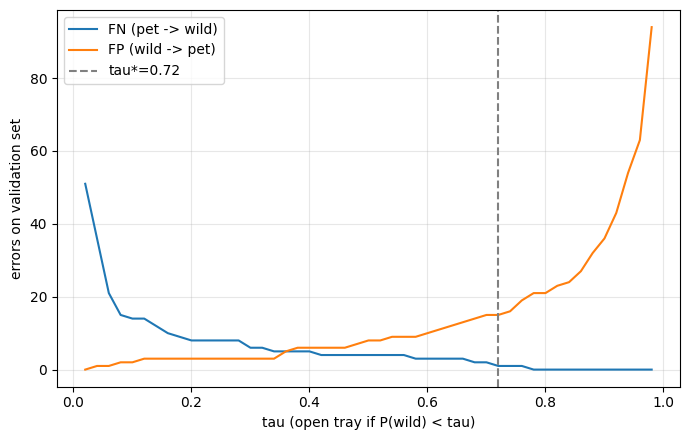

In [ ]:
taus = np.round(np.linspace(0.02, 0.98, 49), 2)
def best_tau(P, Y, c_fn):  # pick tau on VALIDATION only; ties -> closest to 0.5
    return float(min(taus, key=lambda t: (summarize(P, Y, t, c_fn)['cost'], abs(t - 0.5))))

R['threshold'] = {}
for c_fn in (2, 5, 10):
    t = best_tau(P_va, Y_va, c_fn)
    R['threshold'][f'c_fn={c_fn}'] = dict(tau=t,
        test_argmax=summarize(P_te, Y_te, None, c_fn),
        test_tau=summarize(P_te, Y_te, t, c_fn))
    print(f"c_fn={c_fn}: tau*={t}\n  argmax:", R['threshold'][f'c_fn={c_fn}']['test_argmax'],
          "\n  tau*  :", R['threshold'][f'c_fn={c_fn}']['test_tau'])
tau_star = R['threshold']['c_fn=5']['tau']

sw = [summarize(P_va, Y_va, t) for t in taus]
plt.figure(figsize=(7, 4.5))
plt.plot(taus, [x['FN'] for x in sw], label='FN (pet -> wild)')
plt.plot(taus, [x['FP'] for x in sw], label='FP (wild -> pet)')
plt.axvline(tau_star, ls='--', c='gray', label=f'tau*={tau_star}')
plt.xlabel('tau (open tray if P(wild) < tau)'); plt.ylabel('errors on validation set')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig('threshold_sweep.png', dpi=150); plt.show()

In [ ]:
full = models.mobilenet_v2(weights='IMAGENET1K_V1')
full.classifier = make_head(1280)
full.classifier.load_state_dict(head_main.state_dict())
for p in full.features.parameters(): p.requires_grad = False
model = full.to(device).eval()

# Sanity check: the end-to-end model must agree with the head trained on cached features
sub = torch.utils.data.Subset(test_dataset, range(300))
pr = []
with torch.no_grad():
    for x, _ in DataLoader(sub, batch_size=50):
        pr.append(model(x.to(device)).argmax(1).cpu())
agree = float((torch.cat(pr).numpy() == P_te[:300].argmax(1)).mean())
print("Agreement, full model vs cached-feature head:", agree)
R['sanity_agreement'] = agree
torch.save(model.state_dict(), 'model_weights.pth')

Agreement, full model vs cached-feature head: 1.0


### **PART 5: EVALUATION & GradCAM**

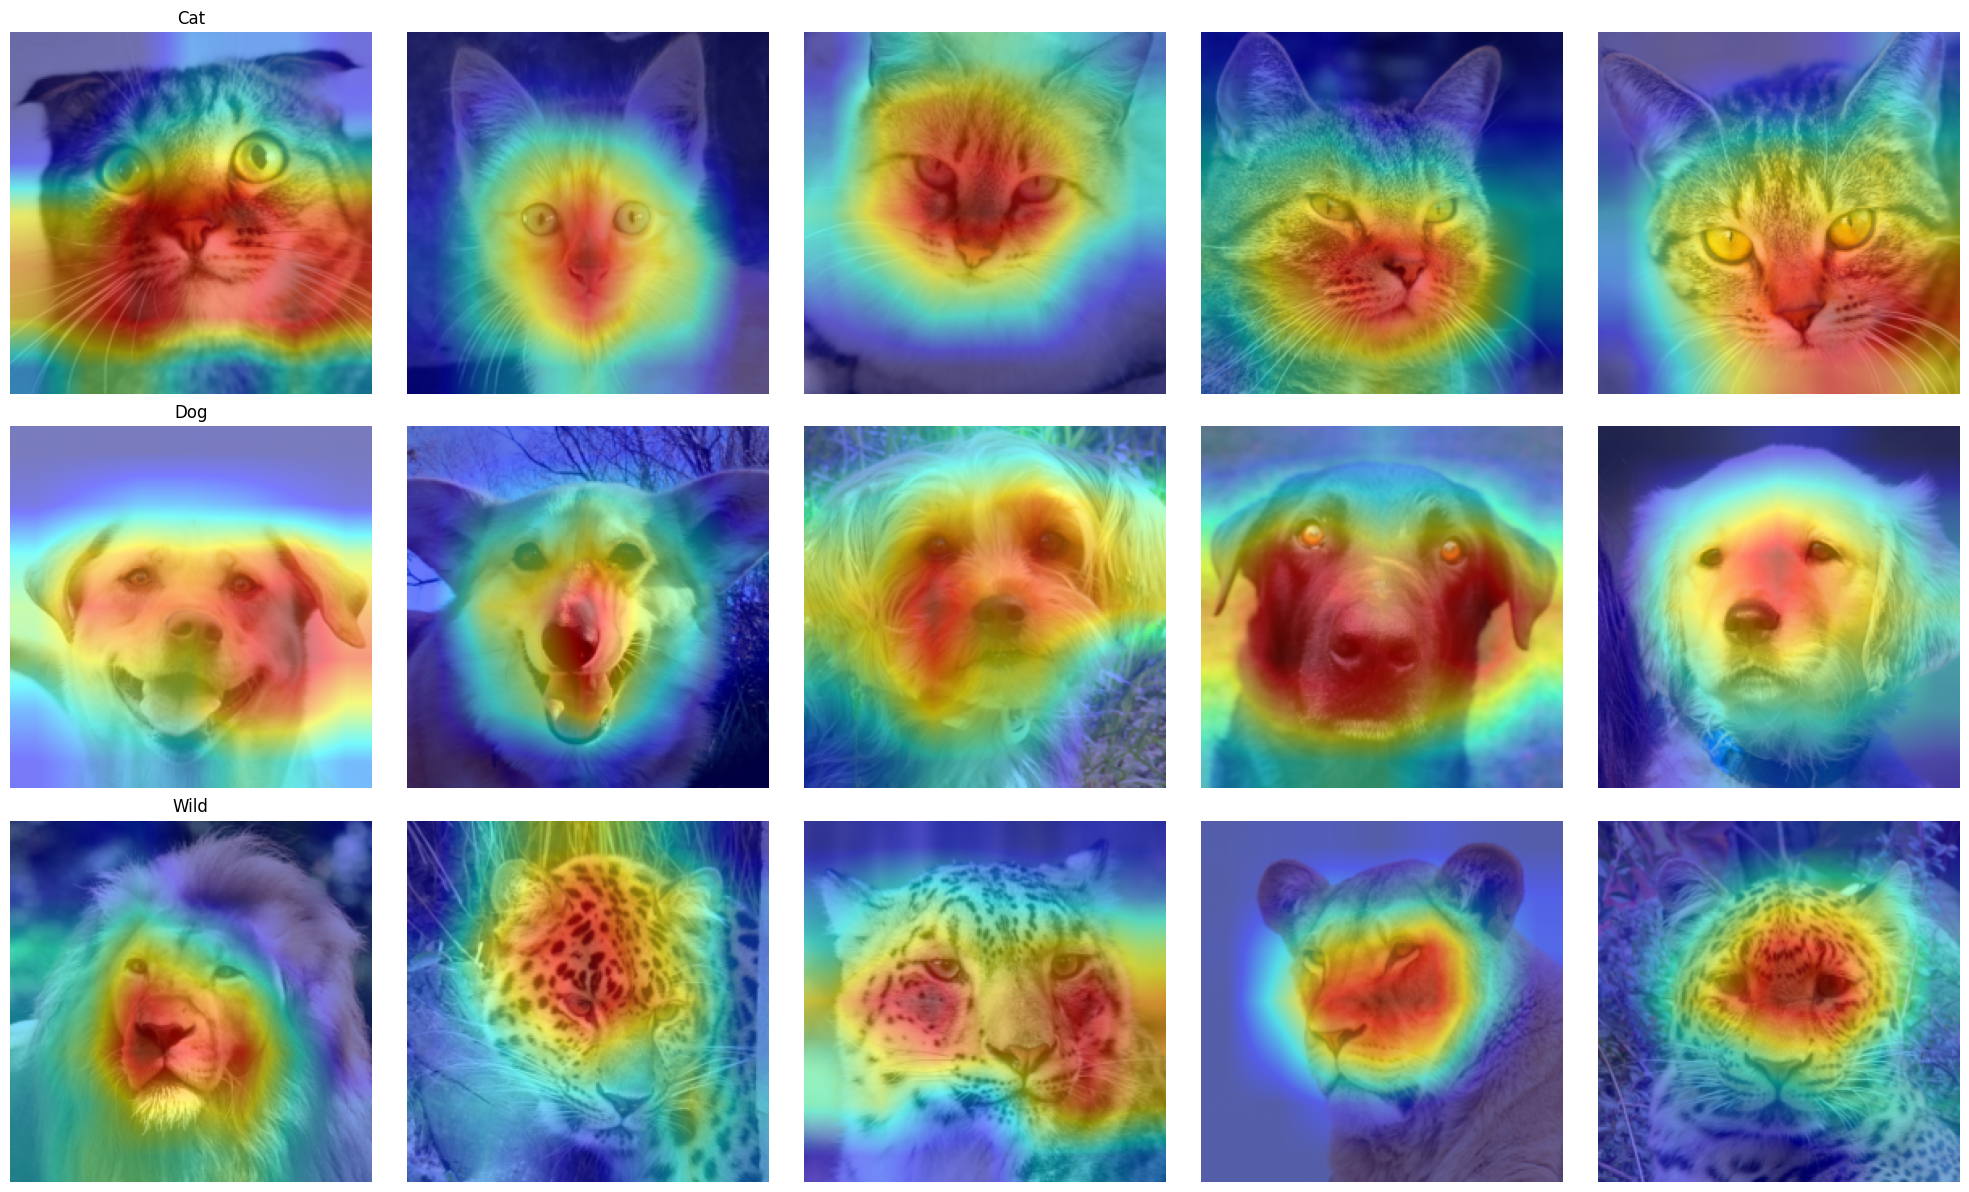

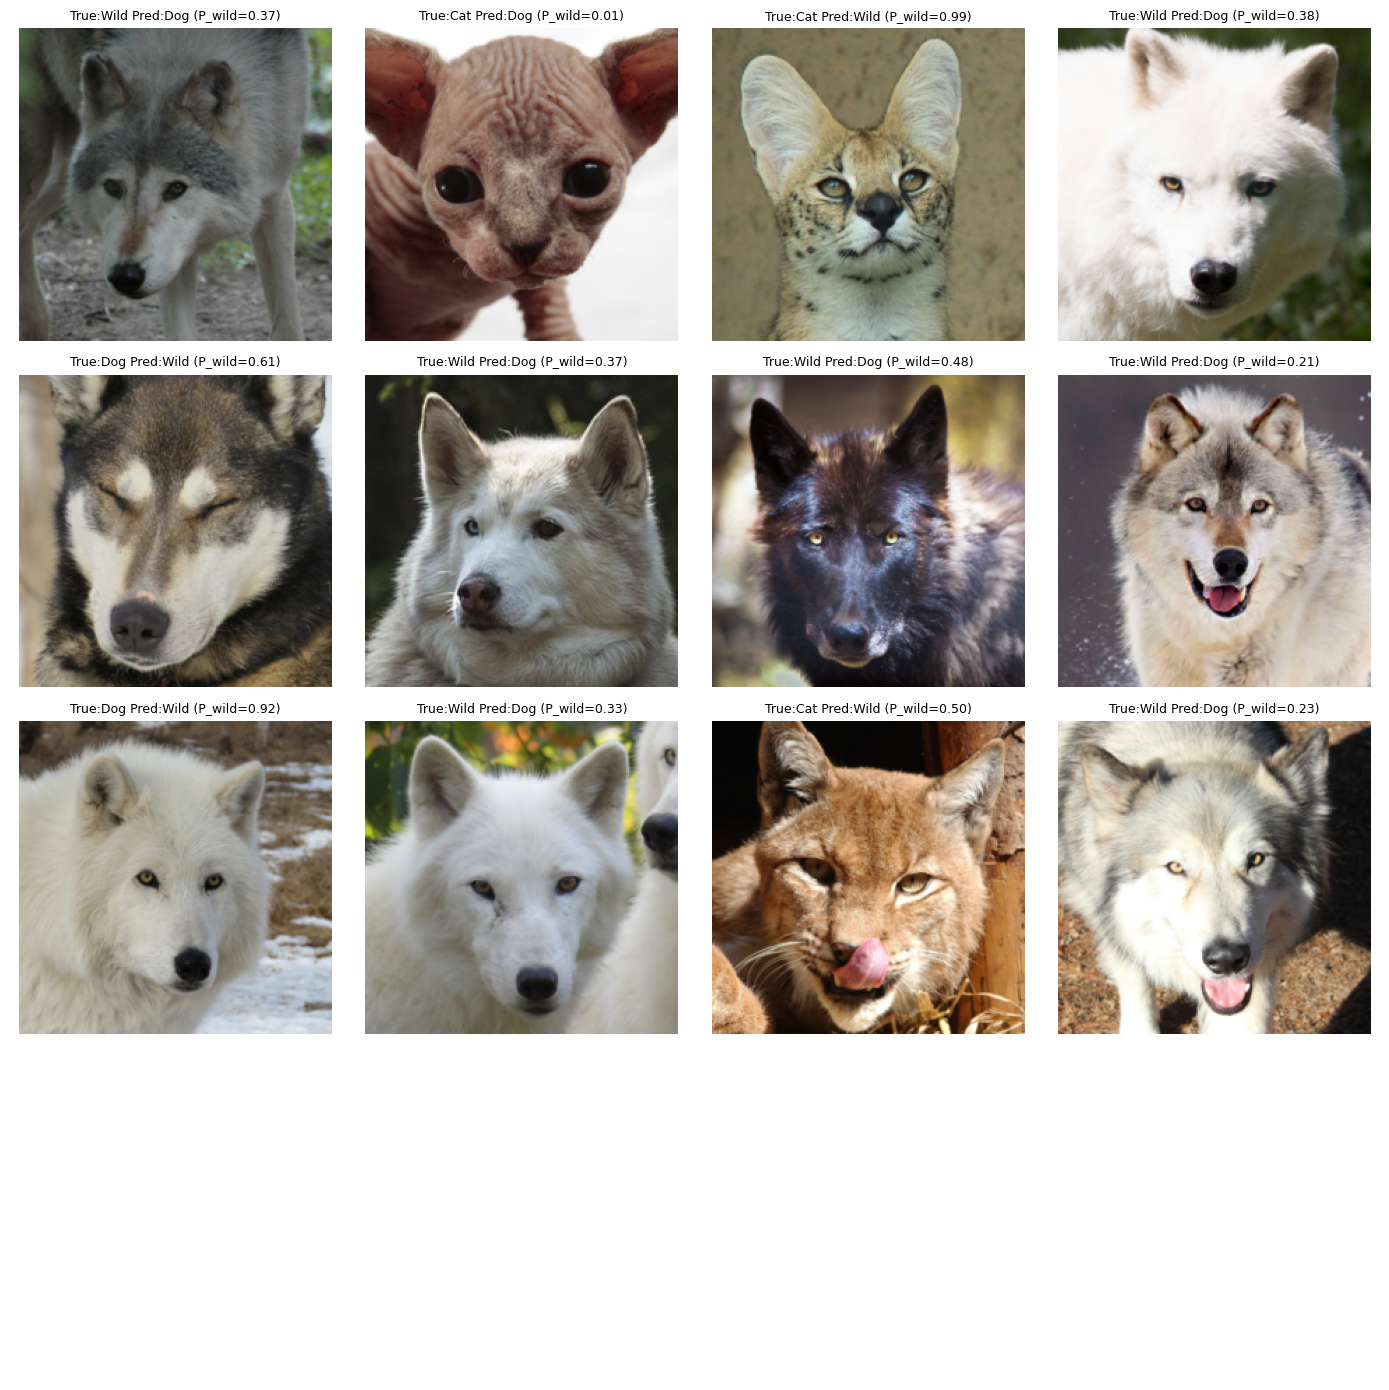

In [ ]:
import cv2
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.gradients = None; self.activations = None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))
    def generate(self, x, target_class):
        self.model.zero_grad()
        out = self.model(x)
        out[0, target_class].backward()
        w = self.gradients.mean(dim=(2, 3), keepdim=True)          # alpha_k^c: pooled gradients
        cam = torch.relu((w * self.activations).sum(dim=1).squeeze())  # ReLU(sum_k alpha_k A^k)
        return (cam / (cam.max() + 1e-8)).cpu().numpy()

grad_cam = GradCAM(model, model.features[-1])
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
rr = random.Random(42)
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for r, name in enumerate(class_names):
    cand = [f for f, l in zip(test_files, test_labels) if l == r]  # TEST images only
    for col, fpath in enumerate(rr.sample(cand, 5)):
        t = transform(Image.open(fpath).convert('RGB'))
        # input needs requires_grad because all model parameters are frozen:
        # without it no autograd graph exists and backward() has nothing to flow through
        x = t.unsqueeze(0).to(device).requires_grad_(True)
        cam = cv2.resize(grad_cam.generate(x, r), (224, 224))
        img = (t.permute(1, 2, 0).numpy() * std + mean).clip(0, 1)
        hm = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0
        axes[r, col].imshow(0.5 * img + 0.5 * hm); axes[r, col].axis('off')
        axes[r, col].set_title(name if col == 0 else '')
plt.tight_layout(); plt.savefig('gradcam.png', dpi=130); plt.show()

# Misclassified test images (main model)
wrong = np.where(pred_te != Y_te)[0][:16]
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, i in zip(axes.flatten(), wrong):
    t, _ = test_dataset[int(i)]
    ax.imshow((t.permute(1, 2, 0).numpy() * std + mean).clip(0, 1)); ax.axis('off')
    ax.set_title(f"True:{class_names[Y_te[i]]} Pred:{class_names[pred_te[i]]} (P_wild={P_te[i,2]:.2f})", fontsize=9)
for ax in axes.flatten()[len(wrong):]: ax.axis('off')
plt.tight_layout(); plt.savefig('errors.png', dpi=130); plt.show()

#### **PART 6: TESTING WITH REAL-LIFE SCENARIOS FOR VALIDATION**
Any animals photos can do. Here, I have my cat and dog, and some wild animals found on the Internet

Saving b5e516f1655346558958c939e85de37a.jpg to b5e516f1655346558958c939e85de37a.jpg
Saving the-quokka-a-native-of-australia-is-famously-known-as-the-v0-04t68sy5e7nf1.webp to the-quokka-a-native-of-australia-is-famously-known-as-the-v0-04t68sy5e7nf1.webp
Saving Millie-the-Wombat_2-scaled-1.jpg to Millie-the-Wombat_2-scaled-1.jpg
Saving WhatsApp Image 2026-09-23 at 19.20.31 (1).jpeg to WhatsApp Image 2026-09-23 at 19.20.31 (1) (1).jpeg
Saving WhatsApp Image 2026-09-23 at 19.20.31.jpeg to WhatsApp Image 2026-09-23 at 19.20.31 (2).jpeg
Saving WhatsApp Image 2026-09-23 at 19.20.32.jpeg to WhatsApp Image 2026-09-23 at 19.20.32 (1).jpeg
Saving WhatsApp Image 2026-09-23 at 17.38.10.jpeg to WhatsApp Image 2026-09-23 at 17.38.10 (1).jpeg
Saving WhatsApp Image 2026-09-23 at 17.39.23.jpeg to WhatsApp Image 2026-09-23 at 17.39.23 (1).jpeg
Saving WhatsApp Image 2026-09-23 at 17.38.54.jpeg to WhatsApp Image 2026-09-23 at 17.38.54 (1).jpeg


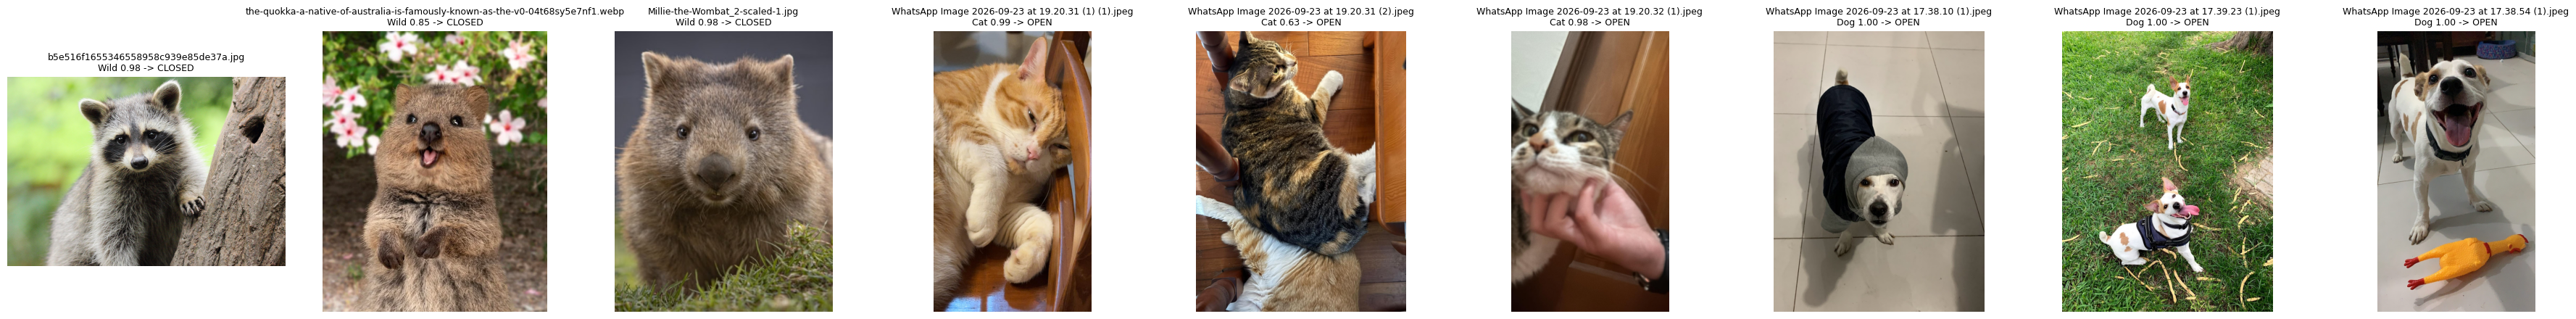

{'file': 'b5e516f1655346558958c939e85de37a.jpg', 'truth': 'b5e516f1655346558958c939e85de37a.jpg', 'pred': 'Wild', 'probs': [0.0, 0.02, 0.98], 'decision': 'CLOSED', 'correct': True}
{'file': 'the-quokka-a-native-of-australia-is-famously-known-as-the-v0-04t68sy5e7nf1.webp', 'truth': 'the-quokka-a-native-of-australia-is-famously-known-as-the-v0-04t68sy5e7nf1.webp', 'pred': 'Wild', 'probs': [0.02, 0.13, 0.85], 'decision': 'CLOSED', 'correct': True}
{'file': 'Millie-the-Wombat_2-scaled-1.jpg', 'truth': 'millie-the-wombat', 'pred': 'Wild', 'probs': [0.0, 0.02, 0.98], 'decision': 'CLOSED', 'correct': True}
{'file': 'WhatsApp Image 2026-09-23 at 19.20.31 (1) (1).jpeg', 'truth': 'whatsapp image 2026-09-23 at 19.20.31 (1) (1).jpeg', 'pred': 'Cat', 'probs': [0.99, 0.01, 0.0], 'decision': 'OPEN', 'correct': False}
{'file': 'WhatsApp Image 2026-09-23 at 19.20.31 (2).jpeg', 'truth': 'whatsapp image 2026-09-23 at 19.20.31 (2).jpeg', 'pred': 'Cat', 'probs': [0.63, 0.26, 0.12], 'decision': 'OPEN', 'cor

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

up = files.upload()
rows = []
fig, axes = plt.subplots(1, len(up), figsize=(4 * len(up), 4.5), squeeze=False)
for ax, fn in zip(axes[0], up):
    img = Image.open(fn).convert('RGB')
    with torch.no_grad():
        p = torch.softmax(model(transform(img).unsqueeze(0).to(device)), 1)[0].cpu().numpy()
    truth = fn.split('_')[0].lower()                 # label taken from the file name prefix
    decision = 'OPEN' if p[2] < tau_star else 'CLOSED'
    ok = (decision == 'OPEN') == (truth in ('cat', 'dog'))
    rows.append(dict(file=fn, truth=truth, pred=class_names[p.argmax()],
                     probs=[round(float(v), 2) for v in p], decision=decision, correct=ok))
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"{fn}\n{class_names[p.argmax()]} {p.max():.2f} -> {decision}", fontsize=9)
plt.tight_layout(); plt.savefig('realworld.png', dpi=130); plt.show()

### **PART 7: REFERENCE**

Dimensi0n. (n.d.). AFHQ 512 [Data set]. Kaggle. https://www.kaggle.com/datasets/dimensi0n/afhq-512

Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D., & Batra, D. (2017). Grad-CAM: Visual explanations from deep networks via gradient-based localization. Proceedings of the IEEE International Conference on Computer Vision, 618–626. https://doi.org/10.1109/ICCV.2017.74

Choi, Y., Uh, Y., Yoo, J., & Ha, J.-W. (2020). StarGAN v2: Diverse image synthesis for multiple domains. CVPR, 8188–8197.

Clopper, C. J., & Pearson, E. S. (1934). The use of confidence or fiducial limits illustrated in the case of the binomial. Biometrika, 26(4), 404–413.

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. CVPR, 770–778.

Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. ICML, 448–456.

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. ICLR.

Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks.
CVPR, 4510–4520.
